In [1]:
# Import the necessary libraries and the class
from   climateScenario import climateScenario
import matplotlib.pyplot as plt
import pandas as pd

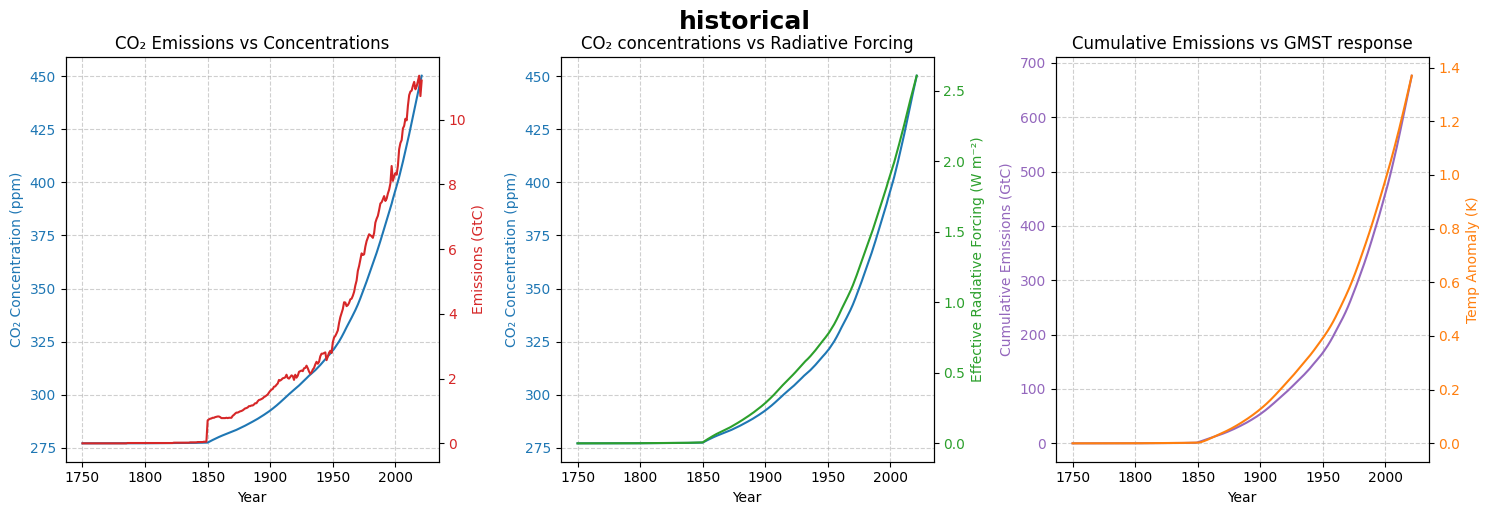

In [2]:
# climateScenario takes two parameters: emissions (either a preset name or a pd.Series with custom emissions data) and name (optional, for custom scenarios)
# Available 'presets' to choose from: 'historical', 'ssp119', 'ssp126', 'ssp245', 'ssp370', 'ssp585', 'abrupt-4xCO2', 'pulseCO2'
# 'historical', 'pulseCO2' are emission-driven, the others are concentration-driven (ssps and abrupt-4xCO2 dont have associated emissions)
hist = climateScenario( 'historical' ) # This defines the scenario
hist.integrate()                       # This runs the model
hist.plotOutput()                      # This plots the output

In [ ]:
hist.outdf

In [ ]:
# This is another example with custom emissions data
# I have created the lowest-emissions scenario possible from EnRoads, and using those emissions to drive the model
# We get to negative emissions by end-of-century
# This scenario is cmip7-like in that it explores some very low emissions futures and strong overshoot (I think there will be a scenario like this in cmip7)

emissionfile   = 'https://svante.mit.edu/~pgiani/emissionsdata/cmip7likeScenario.csv'
emissionData   = pd.read_csv( emissionfile, index_col = 0 )
emissionData.rename( columns = {'GtC': 'CO2emissions_GtC'}, inplace = True )
# If no preset is used, the name parameter is required for the scenario and the emissions must be a pd.Series()
customScenario = climateScenario( emissions = emissionData['CO2emissions_GtC'], name = 'negativeEmissions_EnRoads' )
customScenario.integrate()
customScenario.plotOutput()
plt.show()


In [ ]:
# Finally an example of concentration-driven scenario (ssp245)
ssp245 = climateScenario( 'ssp245' ) # This defines the scenario
ssp245.integrate()                   # This runs the model
ssp245.plotOutput()                  # This plots the output

In [ ]:
# cmip7 scenarios
# Valid options are: high-overshoot, high-extension, verylow, verylow-overshoot, low, medium-extension, medium-overshoot
cmip7 = climateScenario( 'cmip7_high-overshoot' ) # This defines the scenario
cmip7.integrate()                               # This runs the model
cmip7.plotOutput()                              # This plots the output

In [ ]:
# The link with the diffusion model could be something like this:
################
# Input begins #
year  = 2075
month = 3
scenario_selection = 'cmip7_high-overshoot'  # Choose from the available scenarios
## Input ends
################

scenario = climateScenario( scenario_selection )
scenario.integrate()
gmst  = scenario.outdf.loc[ year, 'GMST' ]
print( f"In year {year}, under the {scenario_selection} scenario, the GMST anomaly is {gmst:.2f} °C... Using that for diffusion model" )
# ... diffusion model code here ...